In [1]:
import numpy as np  
import matplotlib.pyplot as plt
import pandas as pd

import torch as th
from torch import nn
import seaborn as sns

In [2]:
df = pd.read_csv('malicious_phish.csv')
df.head()

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [3]:
df.describe()

,url,type
count,651191,651191
unique,641119,4
top,http://style.org.hc360.com/css/detail/mysite/s...,benign
freq,180,428103


In [4]:
df['type'].value_counts()

type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

Text(0, 0.5, 'Count')

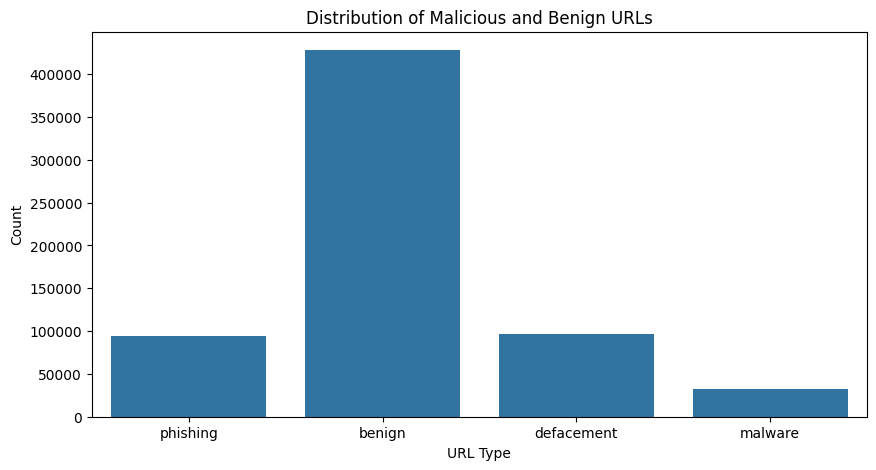

In [5]:
plt.figure(figsize=(10,5))
plt.title('Distribution of Malicious and Benign URLs')
sns.countplot(x='type',data = df)
plt.xlabel('URL Type')
plt.ylabel('Count')


**Feature Engineering**
 
We will now extract features from URLs, and use them to train machine learning model

has_ip_address: It's common for malicious links to have an ip address instead of domain name, this function if url has a IP address in domain.

In [6]:
import re  

def has_ip_address(url):
    # Regular expression to match IPv4 addresses
    match = re.search(
        '(([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.'
        '([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\/)|'  # IPv4
        '((0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\/)' # IPv4 in hexadecimal
        '(?:[a-fA-F0-9]{1,4}:){7}[a-fA-F0-9]{1,4}', url) # IPv6

    if match:
        return 1
    else:
        return 0
    
df['has_ip'] = df['url'].apply(has_ip_address)
df[df['has_ip'] == 1].head()
    

,url,type,has_ip
10408,http://219.232.244.89/intl/update/error_login.htm,phishing,1
12441,boards.ancestry.com/topics.ethnic.natam.nation...,benign,1
12853,http://www.controlyourbreath.com/new/css_/img/...,phishing,1
13161,http://www.reqntpvw.com/Public/softs/everythin...,malware,1
14915,http://66.208.115.70/images/index.asp,phishing,1


In [7]:
df['has_ip'].value_counts()

has_ip
0    643898
1      7293
Name: count, dtype: int64

check_google_index: Will check if the URL is in google search console

In [8]:
from googlesearch import search

def check_google_index(url):
    site = search(url, 5)
    if site:
        return 1
    else:
        return 0

df['in_google_index'] = df['url'].apply(check_google_index)

    

count_dot: checks, if the url has multiple subdomains, by checking the ammount of dots, url's with three or more sub domains are more likely to be malicious 

In [9]:
def count_dot(url):
    return url.count('.')

df['dot_count'] = df['url'].apply(count_dot)

In [10]:
df['dot_count'].value_counts()

dot_count
2     236038
1     219105
3     129667
4      40227
5       9436
6       5729
7       3570
8       1566
9       1150
10      1114
11       973
12       757
13       505
14       379
15       259
16       144
20       129
17       118
19        88
18        70
0         61
22        24
24        22
21        18
23        10
25         9
36         5
27         4
26         4
35         3
42         3
31         1
37         1
34         1
28         1
Name: count, dtype: int64

count_www: Counts the number of www in url, most safe sites will have only one instance of www.

In [11]:
def count_www(url):
    return url.count('www')

df['www_count']=df['url'].apply(count_www)

In [12]:
df['www_count'].value_counts()

www_count
0    525525
1    124178
2      1422
3        58
4         7
5         1
Name: count, dtype: int64

count@: Counts the number of @ in url.

In [13]:
def count_at(url):
    return url.count('@')

df['at_count'] = df['url'].apply(count_at)

In [14]:
df['at_count'].value_counts()

at_count
0     649845
1       1290
2         40
3          9
4          3
10         3
6          1
Name: count, dtype: int64

count_directory: The more directories, the more likely a url is suspicious. 

In [15]:
from urllib.parse import urlparse

def count_directory(url):
    urldir=urlparse(url).path
    return urldir.count('/')

df['directory_count'] = df['url'].apply(count_directory)

In [16]:
df['directory_count'].value_counts()

directory_count
1     208263
2     185322
3     120164
4      53510
5      35379
0      23046
6      14204
7       5671
8       2326
10      1362
9        966
11       343
13       176
12       165
14       161
16        50
15        32
22        12
18        10
17         9
21         5
19         3
24         2
23         2
27         2
39         1
28         1
25         1
20         1
32         1
34         1
Name: count, dtype: int64

count_embedded_domain: Multiple embededded domains generally indicates a link is suspicious 

In [17]:
def count_embedded_domain(url):
    urldir=urlparse(url).path
    return urldir.count('//')

df['embedded_domain_count'] = df['url'].apply(count_embedded_domain)

In [18]:
df['embedded_domain_count'].value_counts()

embedded_domain_count
0    650205
1       974
2        12
Name: count, dtype: int64

suspicious_words: Checks for suspicious words (login, Paypal, bank, etc) which indicate url may be malicious

In [19]:
def suspicious_words(url):
    suspicious_terms = ['login', 'signin', 'secure', 'account', 'update', 'free', 'verify', 'ebayisapi', 'bank', 'ebay', 'paypal', 'click', 'confirm', 'webscr',]
    url_lower = url.lower()
    for term in suspicious_terms:
        if term in url_lower:
            return 1
    return 0

df['suspicious_word'] = df['url'].apply(suspicious_words)

In [20]:
df['suspicious_word'].value_counts()

suspicious_word
0    601202
1     49989
Name: count, dtype: int64

shortening_url: checks if url uses URL shortening services (bit. \ly , goo.gl)

In [21]:
def shortening_url(url):
    shorteners = [
        "bit.ly", "goo.gl", "shorte.st", "go2l.ink", "x.co", "ow.ly", "t.co",
        "tinyurl", "tr.im", "is.gd", "cli.gs", "yfrog.com", "migre.me",
        "ff.im", "tiny.cc", "url4.eu", "twit.ac", "su.pr", "twurl.nl",
        "snipurl.com", "short.to", "BudURL.com", "ping.fm", "post.ly",
        "Just.as", "bkite.com", "snipr.com", "fic.kr", "loopt.us",
        "doiop.com", "short.ie", "kl.am", "wp.me", "rubyurl.com",
        "om.ly", "to.ly", "bit.do", "lnkd.in", "db.tt", "qr.ae",
        "adf.ly", "bitly.com", "cur.lv", "tinyurl.com", "ity.im",
        "q.gs", "po.st", "bc.vc", "twitthis.com", "u.to", "j.mp",
        "buzurl.com", "cutt.us", "u.bb", "yourls.org", "prettylinkpro.com",
        "scrnch.me", "filoops.info", "vzturl.com", "qr.net", "1url.com",
        "tweez.me", "v.gd", "link.zip.net"
    ]

    for service in shorteners:
        if service in url:
            return 1

    return 0
    
df['shortening_url'] = df['url'].apply(shortening_url)

In [22]:
df['shortening_url'].value_counts()

shortening_url
0    611436
1     39755
Name: count, dtype: int64

count_https: Presence of https protocol generally indicates a website is safe.

In [23]:
def count_https(url):
    return url.count('https')

df['https_count'] = df['url'].apply(count_https)

In [24]:
df['https_count'].value_counts()

https_count
0    634768
1     16197
2       183
3        34
5         6
4         3
Name: count, dtype: int64

count_http: Presence of multiple http in url indicates it may be malicious.

In [25]:
def count_http(url):
    return url.count('http')

df['http_count'] = df['url'].apply(count_http)

In [26]:
df['http_count'].value_counts()

http_count
0    461527
1    186625
2      2564
3       455
4        11
9         6
6         2
5         1
Name: count, dtype: int64

count_percent: Safe sites generally will contain less % symbols than malicious sites.

In [27]:
def count_percent(url):
    return url.count('%')

df['percent_count'] = df['url'].apply(count_percent)

In [28]:
df['percent_count'].value_counts()

percent_count
0      623991
1        5824
2        4981
3        2415
6        1710
        ...  
146         1
231         1
198         1
128         1
149         1
Name: count, Length: 124, dtype: int64

count_question: ? are followed by query string that contains data to be passed to server, the more instances of it the more suspicious it's likely to be. 

In [29]:
def count_question(url):
    return url.count('?')   

df['question_count'] = df['url'].apply(count_question)

In [30]:
df['question_count'].value_counts()

question_count
0     511013
1     134983
2       5065
3         69
4         25
5         11
7          7
6          3
11         3
8          3
12         2
13         2
14         1
15         1
20         1
10         1
17         1
Name: count, dtype: int64

count_dash: dashes are added to make malicious websites look legit.

In [31]:
def count_dash(url):
    return url.count('-')

df['dash_count'] = df['url'].apply(count_dash)

In [32]:
df['dash_count'].value_counts()

dash_count
0     377210
1     104187
2      44061
3      27016
4      22128
5      16145
6      12277
7       9347
8       8400
9       6775
10      6050
11      4710
12      3567
13      2769
14      1990
15      1414
16       924
17       694
18       411
19       269
20       186
21       151
22       100
23        88
24        61
25        42
26        35
27        34
28        32
29        26
31        16
30        12
34         9
32         9
35         5
38         5
33         5
47         4
36         4
41         4
40         3
37         3
42         3
39         3
64         3
50         1
48         1
87         1
54         1
Name: count, dtype: int64

count_equal: Equal (=) signs indicate passing of variable values from one page to another, the more present the higher chance an url is suspicious.

In [33]:
def count_equal(url):
    return url.count('=')

df['equal_count'] = df['url'].apply(count_equal)

In [34]:
df['equal_count'].value_counts()    

equal_count
0     510898
1      54747
2      23212
4      21442
3      14951
5      13443
6       5685
9       2391
7       1981
8       1340
10       344
11       212
12       163
19       127
13       118
14        68
15        19
16        10
17         9
18         7
22         7
34         4
24         4
28         3
20         1
21         1
39         1
29         1
51         1
26         1
Name: count, dtype: int64

url_length: Malicious links may contain longer urls to hide domain names

In [35]:
def url_length(url):
    return len(url)

df['url_length'] = df['url'].apply(url_length)

In [36]:
df['url_length'].value_counts()

url_length
31      19023
33      14209
34      12243
27      11967
35      11700
        ...  
2175        1
493         1
586         1
463         1
467         1
Name: count, Length: 549, dtype: int64

hostname_length: A longer hostname is also suspicious 

In [37]:
def hostname_length(url):
    hostname = urlparse(url).netloc
    return len(hostname)

df['hostname_length'] = df['url'].apply(hostname_length)

In [38]:
df['hostname_length'].value_counts()

hostname_length
0      463192
15      15950
13      14592
14      14061
20      12039
        ...  
116         1
83          1
100         1
122         1
179         1
Name: count, Length: 134, dtype: int64

first_dir_length: The length of the first directory is also relevant when figuring out if a link is safe or suspicious 

In [39]:
from tld import get_tld


def first_directory_length(url):
    path = urlparse(url).path
    try:
        return len(path.split('/')[1])
    except:  
        return 0
    
df['first_directory_length'] = df['url'].apply(first_directory_length)

In [40]:
df['first_directory_length'].value_counts()

first_directory_length
9      83387
4      80768
0      77782
6      51283
5      50371
       ...  
241        1
206        1
199        1
154        1
230        1
Name: count, Length: 218, dtype: int64

top_level_domain_length: Top level domain is the domain with the highest level in hierachy of DNS, ex: .com, .ca. Most safe urls top level domain length ranges from 2-3.

In [41]:
def top_level_domain(url):
    try:
        return get_tld(url, as_object=True).tld
    except:
        return ''

df['tld']=df['url'].apply(top_level_domain)

def top_level_domain_length(tld):
    try:
        return len(tld)
    except:
        return -1
    
df['tld_length'] = df['tld'].apply(top_level_domain_length)

In [42]:
df['tld'].value_counts()

tld
             475281
com           71689
de            11331
net            9851
nl             6159
              ...  
ninja             1
org.my            1
hopto.org         1
ilawa.pl          1
gratis            1
Name: count, Length: 544, dtype: int64

In [43]:
df['tld_length'].value_counts()

tld_length
0     475281
3      87461
2      58700
6      16612
5       6214
4       5405
12       458
14       297
7        254
9        118
11       101
16        71
8         50
13        42
15        41
10        30
21        18
17         9
26         8
20         4
27         3
30         3
18         2
25         2
22         2
31         2
39         2
34         1
Name: count, dtype: int64

count_digits: Safe urls generally won't have digits in them.

In [44]:
def count_digits(url):
    digits = 0
    for i in url:
        if i.isnumeric():
            digits+=1
    return digits

df['digit_count'] = df['url'].apply(count_digits)

In [45]:
df['digit_count'].value_counts()

digit_count
0      277500
4       41826
2       36989
1       35880
6       34093
        ...  
206         1
286         1
229         1
194         1
151         1
Name: count, Length: 222, dtype: int64

count_letters: The number of letter is also important as attackers many try to increase length of URL to hide URL. 

In [46]:
def count_letters(url):
    letters = 0
    for i in url:
        if i.isalpha():
            letters+=1
    return letters

df['letter_count'] = df['url'].apply(count_letters)

In [47]:
df['letter_count'].value_counts()

letter_count
26     16704
25     16617
27     15503
24     15142
28     15054
       ...  
364        1
772        1
480        1
485        1
343        1
Name: count, Length: 425, dtype: int64

abnormal_url



In [48]:
def abnormal_url(url):
    hostname = urlparse(url).hostname
    hostname = str(hostname)
    match = re.search(hostname, url)
    if match:      
        return 1
    else:
       
        return 0


df['abnormal_url'] = df['url'].apply(lambda i: abnormal_url(i))

In [49]:
df['abnormal_url'].value_counts()

abnormal_url
0    463185
1    188006
Name: count, dtype: int64

In [50]:
df.head()

,url,type,has_ip,in_google_index,dot_count,www_count,at_count,directory_count,embedded_domain_count,suspicious_word,shortening_url,https_count,http_count,percent_count,question_count,dash_count,equal_count,url_length,hostname_length,first_directory_length,tld,tld_length,digit_count,letter_count,abnormal_url
0,br-icloud.com.br,phishing,0,1,2,0,0,0,0,0,0,0,0,0,0,1,0,16,0,0,,0,0,13,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,1,2,0,0,2,0,0,0,0,0,0,0,0,0,35,0,5,,0,1,29,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,1,2,0,0,3,0,0,0,0,0,0,0,0,0,31,0,7,,0,1,25,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,0,1,3,1,0,1,0,0,0,0,1,0,1,1,4,88,21,9,be,2,7,63,1
4,http://adventure-nicaragua.net/index.php?optio...,defacement,0,1,2,0,0,1,0,0,0,0,1,0,1,1,3,235,23,9,net,3,22,199,1


Label encoding

In [51]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['type_code'] = label_encoder.fit_transform(df['type'])



In [52]:
df.columns

Index(['url', 'type', 'has_ip', 'in_google_index', 'dot_count', 'www_count',
       'at_count', 'directory_count', 'embedded_domain_count',
       'suspicious_word', 'shortening_url', 'https_count', 'http_count',
       'percent_count', 'question_count', 'dash_count', 'equal_count',
       'url_length', 'hostname_length', 'first_directory_length', 'tld',
       'tld_length', 'digit_count', 'letter_count', 'abnormal_url',
       'type_code'],
      dtype='object')

In [53]:
x = df[['has_ip', 'in_google_index', 'dot_count', 'www_count', 'at_count', 'directory_count', 'embedded_domain_count', 'suspicious_word', 
        'shortening_url', 'https_count', 'http_count', 'percent_count', 'question_count', 'dash_count', 'equal_count', 'url_length', 
        'hostname_length', 'first_directory_length', 'tld_length', 'digit_count', 'letter_count', 'abnormal_url'
        ]]

y = df['type_code']

Spliting the dataset

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train,Y_test = train_test_split(x,y,test_size=0.2, random_state=42)

X_train


,has_ip,in_google_index,dot_count,www_count,at_count,directory_count,embedded_domain_count,suspicious_word,shortening_url,https_count,http_count,percent_count,question_count,dash_count,equal_count,url_length,hostname_length,first_directory_length,tld_length,digit_count,letter_count,abnormal_url
461072,0,1,2,0,0,2,0,0,0,0,0,0,0,0,0,40,0,4,0,0,34,0
621879,0,1,2,0,0,2,0,0,0,0,0,0,0,0,0,26,0,4,0,3,19,0
376801,0,1,2,0,0,2,0,0,0,0,0,0,0,0,0,30,0,4,0,0,26,0
560108,0,1,1,0,0,4,0,0,0,0,0,0,0,1,0,42,0,11,0,0,36,0
454327,0,1,2,0,0,1,0,0,0,0,0,0,0,0,0,25,0,7,0,0,22,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644167,0,1,3,1,0,1,0,0,1,0,0,0,0,0,0,32,0,16,0,0,27,0
259178,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,15,0,0,0,3,11,0
365838,0,1,3,1,0,1,0,0,0,0,1,0,1,1,5,98,17,9,2,11,67,1
131932,0,1,2,0,0,3,0,0,0,0,0,0,0,0,0,53,0,11,0,7,39,0


Creating the model. 

In [55]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def result (y_pred,y_test):
    accuracy=accuracy_score(y_test, y_pred)*100

    precision,recall,f1_score,support = precision_recall_fscore_support(y_test, y_pred, average='weighted')

    result={
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score
    }

    print(classification_report(y_test, y_pred,target_names=['benign','defacement','phishing','malware']))

    return result

In [56]:
from sklearn.metrics import confusion_matrix

def create_confusion_matrix(y_test,y_pred):
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=['benign','defacement','phishing','malware'], columns=['benign','defacement','phishing','malware'])
    plt.figure(figsize=(8,6))
    sns.heatmap(cm_df, annot=True, fmt='.1f')
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

c:\Users\shiva\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic 

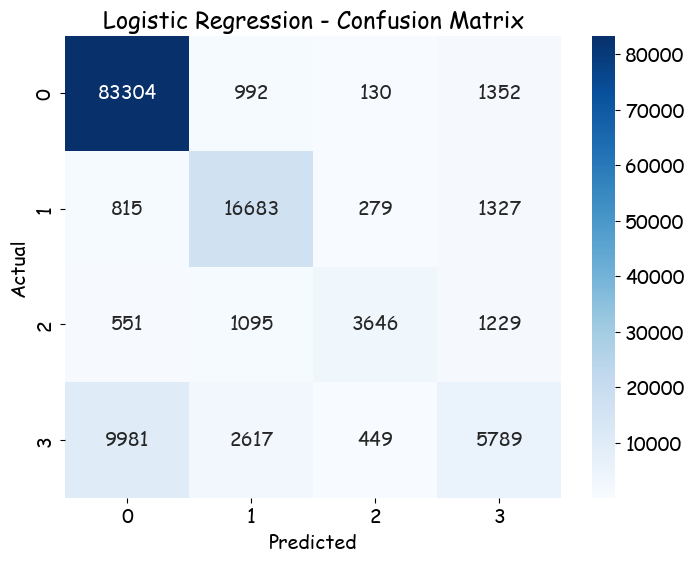

Logistic Regression - Train Metrics:
Train accuracy: 0.8401
Train precision: 0.8208
Train recall: 0.8401
Train F1-score: 0.8208
Logistic Regression - Test Metrics:
Test accuracy: 0.8402
Test precision: 0.8210
Test recall: 0.8402
Test F1-score: 0.8208


findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

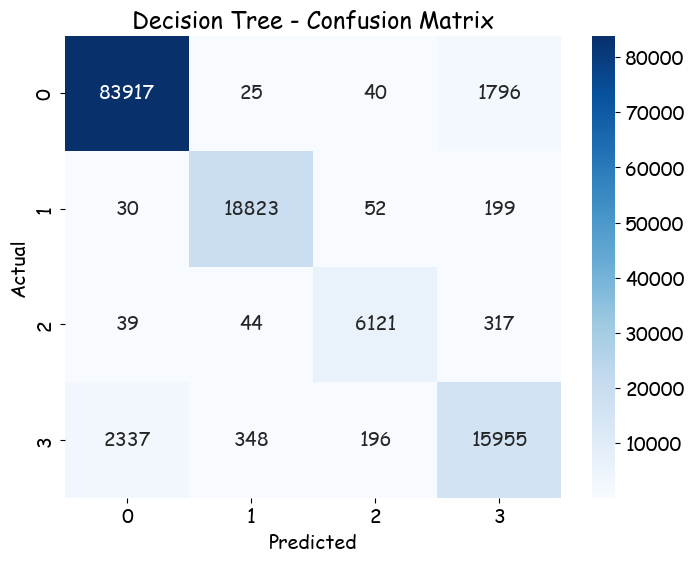

Decision Tree - Train Metrics:
Train accuracy: 0.9863
Train precision: 0.9863
Train recall: 0.9863
Train F1-score: 0.9862
Decision Tree - Test Metrics:
Test accuracy: 0.9584
Test precision: 0.9579
Test recall: 0.9584
Test F1-score: 0.9581


findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

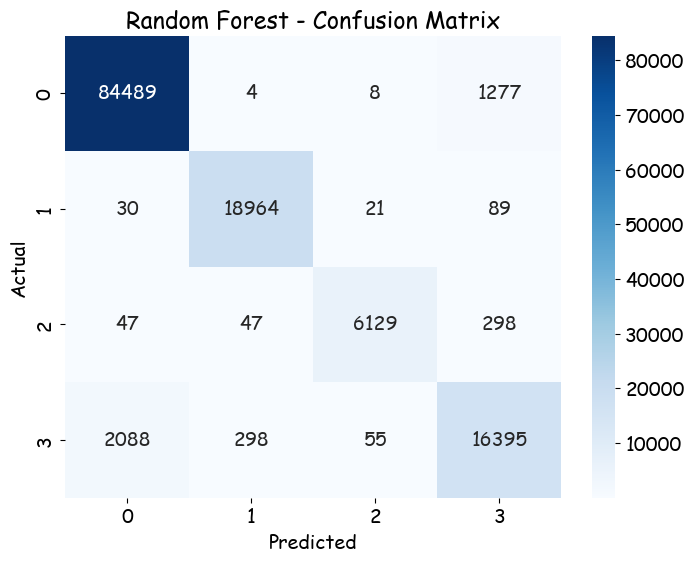

Random Forest - Train Metrics:
Train accuracy: 0.9863
Train precision: 0.9863
Train recall: 0.9863
Train F1-score: 0.9863
Random Forest - Test Metrics:
Test accuracy: 0.9673
Test precision: 0.9669
Test recall: 0.9673
Test F1-score: 0.9670


findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

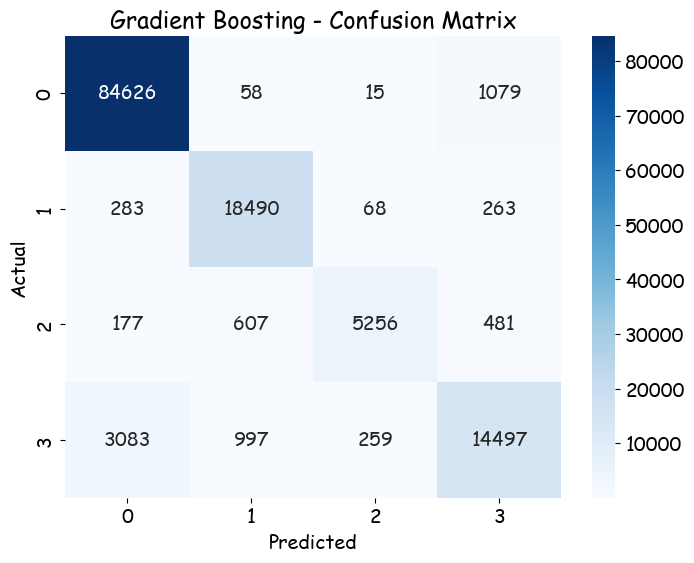

Gradient Boosting - Train Metrics:
Train accuracy: 0.9433
Train precision: 0.9420
Train recall: 0.9433
Train F1-score: 0.9415
Gradient Boosting - Test Metrics:
Test accuracy: 0.9434
Test precision: 0.9422
Test recall: 0.9434
Test F1-score: 0.9417


findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

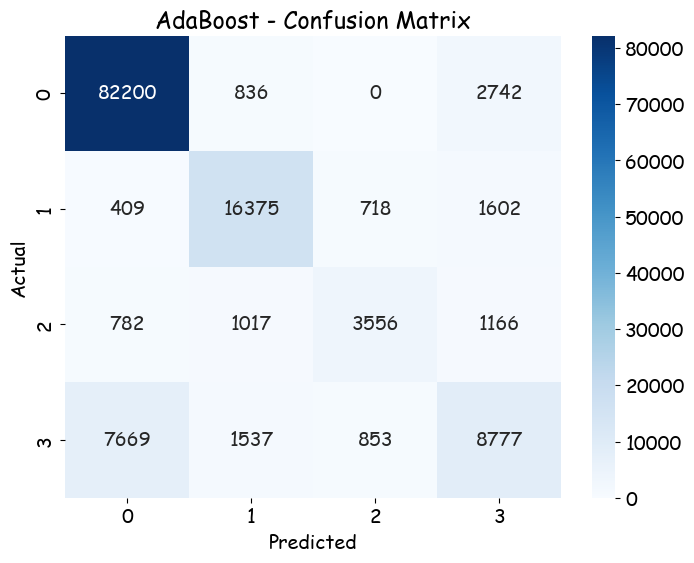

AdaBoost - Train Metrics:
Train accuracy: 0.8516
Train precision: 0.8393
Train recall: 0.8516
Train F1-score: 0.8428
AdaBoost - Test Metrics:
Test accuracy: 0.8516
Test precision: 0.8396
Test recall: 0.8516
Test F1-score: 0.8431


findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

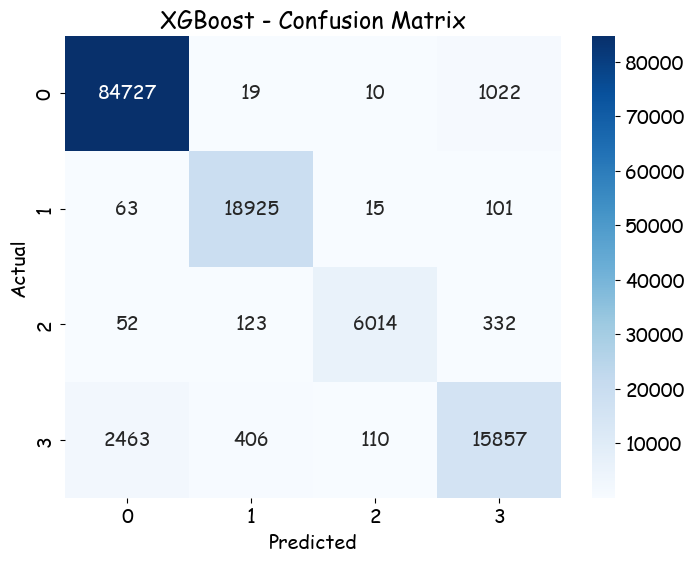

XGBoost - Train Metrics:
Train accuracy: 0.9652
Train precision: 0.9646
Train recall: 0.9652
Train F1-score: 0.9645
XGBoost - Test Metrics:
Test accuracy: 0.9638
Test precision: 0.9632
Test recall: 0.9638
Test F1-score: 0.9631


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from termcolor import colored

#Defining classifiers
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

for model_name,model in models.items():
    
    model.fit(X_train,Y_train)

    #Predctions on test and train data
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    #Calculating metrics for train data
    train_accuracy = accuracy_score(Y_train, y_train_pred)
    train_precision = precision_score(Y_train, y_train_pred, average='weighted')
    train_recall = recall_score(Y_train, y_train_pred, average='weighted')
    train_f1 = f1_score(Y_train, y_train_pred, average='weighted')

    #Calculating metrics for test data
    accuracy = accuracy_score(Y_test, y_test_pred)
    precision = precision_score(Y_test, y_test_pred, average='weighted')
    recall = recall_score(Y_test, y_test_pred, average='weighted')
    f1 = f1_score(Y_test, y_test_pred, average='weighted')

    #Generating confusion matrix
    cm = confusion_matrix(Y_test, y_test_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm,annot=True, cmap='Blues', fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

    #Printing train results
    print(colored(f'{model_name} - Train Metrics:', 'blue'))
    print(f'Train accuracy: {train_accuracy:.4f}')
    print(f'Train precision: {train_precision:.4f}')
    print(f'Train recall: {train_recall:.4f}')
    print(f'Train F1-score: {train_f1:.4f}')

    #Printing test results
    print(colored(f'{model_name} - Test Metrics:', 'green'))
    print(f'Test accuracy: {accuracy:.4f}')
    print(f'Test precision: {precision:.4f}')
    print(f'Test recall: {recall:.4f}')
    print(f'Test F1-score: {f1:.4f}')
    

Hyperparameter tuning

In [ ]:
#Logistic Regression 
logistic_regression_parameters = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'multiclass': ['auto', 'multinomial']
}

#Decision Tree
decision_tree_parameters = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

#Random Forest
random_forest_parameters = {
    'n_estimators': [100, 200, 300,400,500],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

#Gradient Boosting
gradient_boosting_parameters = {
    'n_estimators': [100, 200 ,500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

#XGBoost
xgb_parameters = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 10],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.5,0.8, 1.0],
    'colsample_bytree': [0.5, 0.8, 1.0]
}

#CatBoost
catboost_parameters = {
    'learning_rate': [0.01, 0.1, 1],
    'n_estimators': [100, 200, 500],
    'depth': [3, 5, 10],
    'min_data_in_leaf': [1, 3, 5],
    'l2_leaf_reg': [1, 3, 5],
}

#AdaBoost
adaboost_parameters = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1],
    'algorithm': ['SAMME', 'SAMME.R']
}

#Setting up hyperparameter tuning for each model

parameters = {
    'Logistic Regression': logistic_regression_parameters, 
    'Decision Tree': decision_tree_parameters,
    'Random Forest': random_forest_parameters,
    'Gradient Boosting': gradient_boosting_parameters,
    'XGBoost': xgb_parameters,
    'CatBoost': catboost_parameters,
    'AdaBoost': adaboost_parameters
}


In [ ]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold
from sklearn.metrics import accuracy_score,make_scorer

#Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring_metric = make_scorer(accuracy_score)

#Grid search for each model
for model_name, model in models.items():
    print(colored(f'Tuning hyperparameters for {model_name}...', 'red',attrs=['bold']))

    clf = GridSearchCV(model, parameters[model_name],scoring=scoring_metric,cv=cv,)

    clf.fit(X_train, Y_train)

    print(f"Best hyperparameters for {model_name}: {clf.best_params_}")
    print(f"Train Accuracy with best hyperparameters: {clf.best_score_:.4f}")
    print(f"Validation Accuracy with best hyperparameters: {clf.score(X_test, Y_test):.4f}")

    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    #Calculate performance metrics for Train data
    train_accuracy = accuracy_score(Y_train, y_train_pred)
    train_precision = precision_score(Y_train, y_train_pred, average='weighted')
    train_recall = recall_score(Y_train, y_train_pred, average='weighted')
    train_f1 = f1_score(Y_train, y_train_pred, average='weighted')

    #Calculate performance metrics for Test data
    accuracy = accuracy_score(Y_test, y_test_pred)
    precision = precision_score(Y_test, y_test_pred, average='weighted')
    recall = recall_score(Y_test, y_test_pred, average='weighted')
    f1 = f1_score(Y_test, y_test_pred, average='weighted')

    #Confusion matrix
    cm = confusion_matrix(Y_test, y_test_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
    plt.title(f'{model_name} - Confusion Matrix (Tuned)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    print(colored(f'{model_name} - Train Metrics:', 'blue'))
    print(f'Train accuracy: {train_accuracy:.4f}')
    print(f'Train precision: {train_precision:.4f}')
    print(f'Train recall: {train_recall:.4f}')
    print(f'Train F1-score: {train_f1:.4f}')

    #Printing test results
    print(colored(f'{model_name} - Test Metrics:', 'green'))
    print(f'Test accuracy: {accuracy:.4f}')
    print(f'Test precision: {precision:.4f}')
    print(f'Test recall: {recall:.4f}')
    print(f'Test F1-score: {f1:.4f}')
